# Laboratorio 5 - Clasificación de tweets usando minería de texto

**Curso:** CC3084 - Data Science  
**Integrantes:** Osman de León y Milton Polanco  
**Repositorio:** [GitHub - Lab-MineriayAnalisis](https://github.com/Emadlgg/Data_Science/tree/main/Lab-MineriayAnalisis)  
**Universidad del Valle de Guatemala**  
**Fecha:** 30 de agosto de 2026

El objetivo es clasificar tweets como desastre real (`target=1`) o no desastre (`target=0`). Ademas del análisis exploratorio, se comparan varios modelos, se construye una función para clasificar texto nuevo y se estudia si una variable de negatividad mejora la predicción.

Los datos provienen de la competencia [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/overview) de Kaggle.

## 1. Librerías y configuración

Se utiliza `pandas` para los datos, `nltk` para stopwords y sentimiento, `scikit-learn` para vectorización y modelos, y `matplotlib`, `seaborn` y `wordcloud` para las gráficas. Las semillas se fijan en 42 para que los resultados sean reproducibles.

In [1]:
from pathlib import Path
from collections import Counter
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

from scipy.sparse import hstack, csr_matrix
from scipy.stats import mannwhitneyu

from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})

# Permite ejecutar desde la carpeta notebooks o desde la raiz del laboratorio.
ROOT = Path("..") if Path("../data/train.csv").exists() else Path(".")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "reporte" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)

for recurso in ["stopwords", "vader_lexicon"]:
    nltk.download(recurso, quiet=True)

STOPWORDS = set(stopwords.words("english"))
print("Librerias cargadas. Carpeta de datos:", DATA_DIR.resolve())

Librerias cargadas. Carpeta de datos: C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 5\Data_Science\Lab-MineriayAnalisis\data


## 2. Carga y descripción de los datos

`train.csv` contiene las etiquetas usadas para entrenar y evaluar. `test.csv` no contiene `target`, porque esta pensado para enviar predicciones a Kaggle. El análisis estadístico se hace con las 7,613 observaciones etiquetadas.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("Train:", train.shape)
print("Test: ", test.shape)
display(train.head())

Train: (7613, 5)
Test:  (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
resumen_columnas = pd.DataFrame({
    "tipo": train.dtypes.astype(str),
    "nulos": train.isna().sum(),
    "porcentaje_nulos": (100 * train.isna().mean()).round(2),
    "valores_unicos": train.nunique()
})
display(resumen_columnas)

,tipo,nulos,porcentaje_nulos,valores_unicos
id,int64,0,0.00,7613
keyword,str,61,0.80,221
location,str,2533,33.27,3341
text,str,0,0.00,7503
target,int64,0,0.00,2


`location` tiene 33.27% de valores faltantes y 3,341 formas distintas de escritura. Estandarizar ciudades, paises y abreviaturas sería un problema adicional, por lo que no se usa como predictor. `keyword` tiene pocos nulos, pero la función solicitada por la guia solamente recibe el texto de un tweet; para que entrenamiento y uso sean consistentes, el modelo final se basa en `text`.

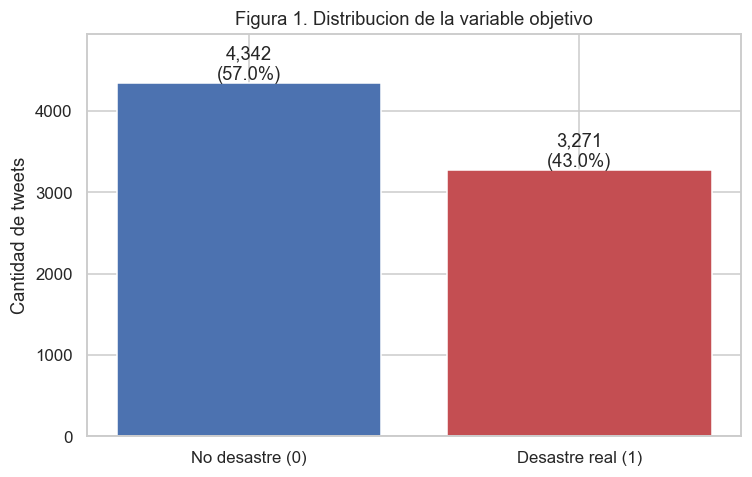

In [4]:
conteo_target = train["target"].value_counts().sort_index()
porcentaje_target = 100 * train["target"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["No desastre (0)", "Desastre real (1)"], conteo_target,
              color=["#4C72B0", "#C44E52"])
ax.set(title="Figura 1. Distribucion de la variable objetivo", ylabel="Cantidad de tweets")
for bar, n, pct in zip(bars, conteo_target, porcentaje_target):
    ax.text(bar.get_x() + bar.get_width()/2, n + 40, f"{n:,}\n({pct:.1f}%)", ha="center")
ax.set_ylim(0, conteo_target.max() * 1.14)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribucion_target.png", bbox_inches="tight")
plt.show()

La clase 0 representa 57.0% y la clase 1 representa 43.0%. No es un desbalance severo, pero se conserva la proporción con particiones estratificadas y se reporta F1 además de exactitud.

n_caracteres               n_palabras             
               mean median    std       mean median   std
target                                                   
0             95.71  101.0  35.89      14.70   15.0  6.16
1            108.11  115.0  29.31      15.17   15.0  5.10

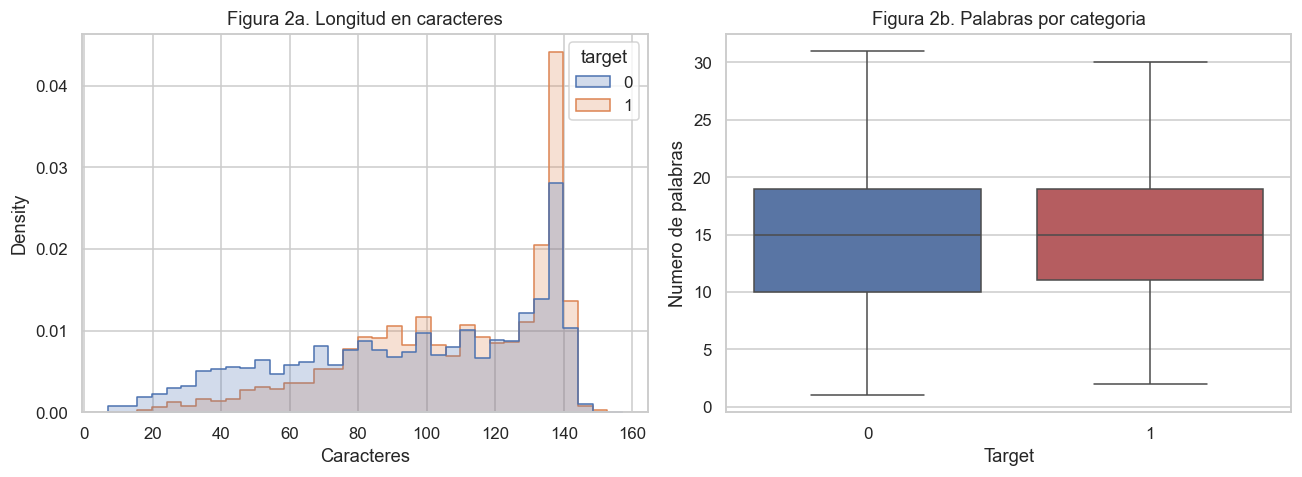

In [5]:
train["n_caracteres"] = train["text"].str.len()
train["n_palabras"] = train["text"].str.split().str.len()

display(train.groupby("target")[["n_caracteres", "n_palabras"]].agg(["mean", "median", "std"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=train, x="n_caracteres", hue="target", bins=35,
             element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set(title="Figura 2a. Longitud en caracteres", xlabel="Caracteres")
sns.boxplot(data=train, x="target", y="n_palabras", hue="target",
            palette=["#4C72B0", "#C44E52"], legend=False, ax=axes[1])
axes[1].set(title="Figura 2b. Palabras por categoria", xlabel="Target", ylabel="Numero de palabras")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_longitud_tweets.png", bbox_inches="tight")
plt.show()

Los tweets de desastre real son un poco más largos, tanto en caracteres como en palabras. Esta diferencia ayuda a describir el conjunto, pero no se agrega como variable separada porque TF-IDF ya representa gran parte de la información del texto.

## 3. Limpieza y preprocesamiento

Se aplicaron estas tareas sobre una copia del texto:

1. Conversión a minusculas.
2. Eliminación de URL y menciones de usuarios.
3. Eliminación del símbolo `#`, conservando la palabra del hashtag.
4. Eliminación de emojis y caracteres no ASCII para la representación TF-IDF.
5. Eliminación de números, excepto `911` por su posible relación con emergencias.
6. Eliminación de puntuación y apóstrofes.
7. Eliminación de stopwords en inglés con el corpus de NLTK.
8. Eliminación de tokens de un solo caracter y espacios repetidos.

Para sentimiento se conserva el texto original, ya que VADER aprovecha mayúsculas, puntuación, emoticones y negaciones. Usar el texto agresivamente limpiado en esa parte descartaria información afectiva.

In [ ]:
def limpiar_texto(texto):
    '''Limpia un tweet para frecuencias y modelos de clasificacion.'''
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", " ")
    texto = re.sub(r"[^\x00-\x7F]+", " ", texto)
    # El lookahead evita borrar 911.
    texto = re.sub(r"\b(?!911\b)\d+(?:[.,]\d+)*\b", " ", texto)
    texto = texto.translate(str.maketrans("", "", string.punctuation))
    tokens = [
        token for token in texto.split()
        if token not in STOPWORDS and len(token) > 1
    ]
    return " ".join(tokens)

train["text_clean"] = train["text"].apply(limpiar_texto)
test["text_clean"] = test["text"].apply(limpiar_texto)

assert limpiar_texto("@uvg Call 911! Send 2 medics https://x.com") == "call 911 send medics"
display(train[["text", "text_clean"]].sample(6, random_state=42))

,text,text_clean
2644,So you have a new weapon that can cause un-ima...,new weapon cause unimaginable destruction
2227,The f$&amp;@ing things I do for #GISHWHES Just...,famp things gishwhes got soaked deluge going p...
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,dt rt col police catch pickpocket liverpool stree
132,Aftershock back to school kick off was great. ...,aftershock back school kick great want thank e...
6845,in response to trauma Children of Addicts deve...,response trauma children addicts develop defen...
5559,@Calum5SOS you look like you got caught in a r...,look like got caught rainstorm amazing disgust...


El ejemplo y la asercion muestran que `911` se conserva, mientras que la mencion, el numero 2 y la URL se eliminan. No se aplicó stemming ni lematización: las flexiones pueden conservar matices utiles y el vocabulario del conjunto todavia es manejable.

## 4. Unigramas, bigramas y trigramas

Un n-grama es una secuencia de `n` palabras contiguas. Ademas de la frecuencia absoluta se calcula la probabilidad empírica dentro de cada categoría:

\[
P(g\mid c)=\frac{\text{frecuencia del n-grama }g\text{ en la categoría }c}
{\text{total de n-gramas observados en }c}
\]

Esta probabilidad permite comparar n-gramas aunque las categorías tengan diferente cantidad de tweets.

In [7]:
def tabla_ngramas(serie, n=1, top=20):
    vectorizador = CountVectorizer(ngram_range=(n, n))
    matriz = vectorizador.fit_transform(serie)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    total = frecuencias.sum()
    tabla = pd.DataFrame({
        "ngrama": vectorizador.get_feature_names_out(),
        "frecuencia": frecuencias,
        "probabilidad": frecuencias / total
    })
    return tabla.sort_values("frecuencia", ascending=False).head(top).reset_index(drop=True)

unigramas_0 = tabla_ngramas(train.loc[train.target == 0, "text_clean"], n=1)
unigramas_1 = tabla_ngramas(train.loc[train.target == 1, "text_clean"], n=1)
bigramas_0 = tabla_ngramas(train.loc[train.target == 0, "text_clean"], n=2, top=15)
bigramas_1 = tabla_ngramas(train.loc[train.target == 1, "text_clean"], n=2, top=15)
trigramas_0 = tabla_ngramas(train.loc[train.target == 0, "text_clean"], n=3, top=10)
trigramas_1 = tabla_ngramas(train.loc[train.target == 1, "text_clean"], n=3, top=10)

display(pd.concat({"No desastre": unigramas_0, "Desastre real": unigramas_1}, axis=1))

No desastre                         Desastre real                        
        ngrama frecuencia probabilidad        ngrama frecuencia probabilidad
0         like        253     0.006987          fire        181     0.005975
1           im        244     0.006738          news        138     0.004556
2          amp        193     0.005330           via        121     0.003994
3          new        171     0.004722      disaster        117     0.003862
4          get        163     0.004501    california        111     0.003664
5         dont        141     0.003894       suicide        110     0.003631
6          one        129     0.003562           amp        109     0.003598
7         body        113     0.003121        police        107     0.003532
8          via         99     0.002734        people        105     0.003466
9        would         97     0.002679        killed         93     0.003070
10       video         96     0.002651          like         92     0.003037
11        love         90     0.002485     hiroshima         88     0.002905
12      people         90     0.002485         fires         86     0.002839
13          us         86     0.002375         storm         85     0.002806
14        know         85     0.002347         crash         84     0.002773
15        back         84     0.002320            us         82     0.002707
16         got         83     0.002292      families         81     0.002674
17        time         82     0.002265         train         79     0.002608
18         see         82     0.002265     emergency         76     0.002509
19        full         82     0.002265     buildings         76     0.002509

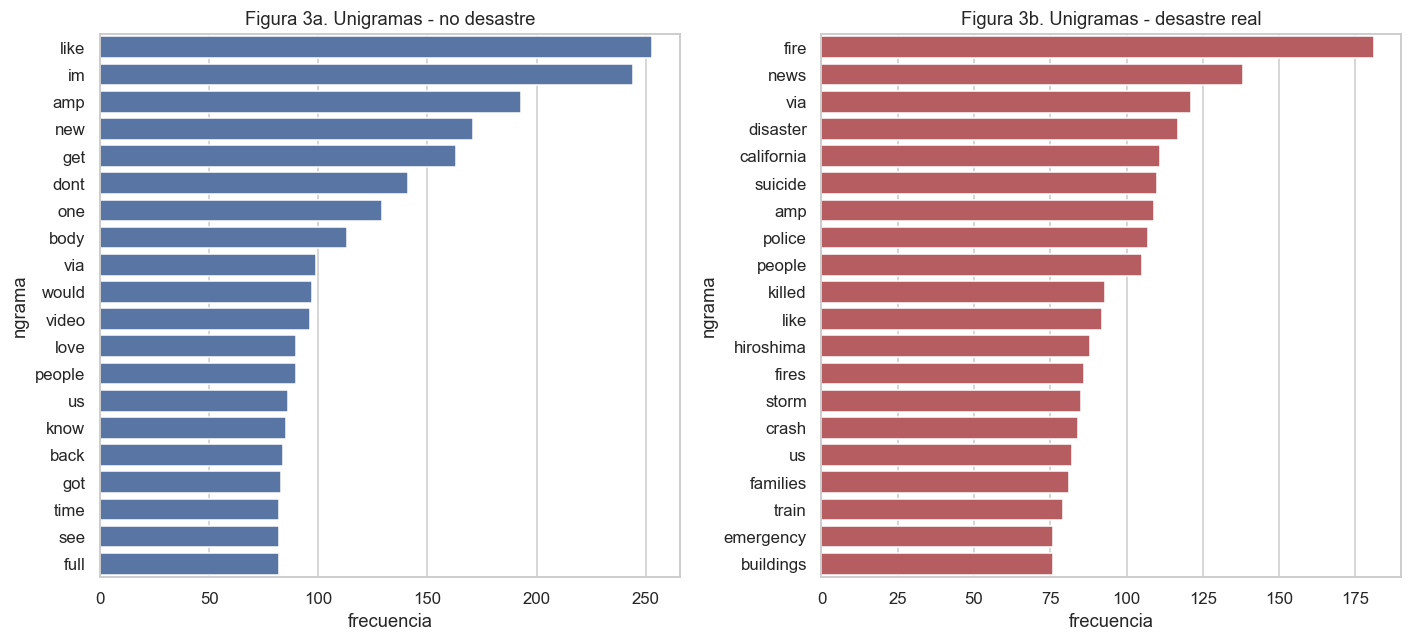

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(data=unigramas_0, y="ngrama", x="frecuencia", color="#4C72B0", ax=axes[0])
axes[0].set_title("Figura 3a. Unigramas - no desastre")
sns.barplot(data=unigramas_1, y="ngrama", x="frecuencia", color="#C44E52", ax=axes[1])
axes[1].set_title("Figura 3b. Unigramas - desastre real")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_unigramas.png", bbox_inches="tight")
plt.show()

`fire` es el unigrama más frecuente entre desastres reales, mientras que `like` encabeza los tweets que no son desastre. Palabras como `flood`, `killed`, `disaster`, `storm` y `fires` parecen utiles para clasificar. Sin embargo, términos como `fire`, `emergency` o `death` aparecen en ambos grupos; una palabra aislada no distingue entre un hecho real y una metafora.

No desastre                                Desastre real  \
                  ngrama frecuencia probabilidad               ngrama   
0             cross body         38     0.001192       suicide bomber   
1            liked video         34     0.001067  northern california   
2              full read         28     0.000879            oil spill   
3               body bag         27     0.000847    burning buildings   
4           body bagging         23     0.000722      suicide bombing   
5      burning buildings         23     0.000722  california wildfire   
6   quarantine offensive         21     0.000659     bomber detonated   
7              body bags         21     0.000659          homes razed   
8             looks like         21     0.000659      confirmed mh370   
9      reddit quarantine         21     0.000659       razed northern   
10        content policy         20     0.000628             16yr old   
11             feel like         20     0.000628       detonated bomb   
12     offensive content         20     0.000628          pkk suicide   
13         prebreak best         17     0.000533         latest homes   
14             loud bang         17     0.000533          mass murder   

                            
   frecuencia probabilidad  
0          59     0.002183  
1          41     0.001517  
2          38     0.001406  
3          36     0.001332  
4          34     0.001258  
5          34     0.001258  
6          30     0.001110  
7          29     0.001073  
8          29     0.001073  
9          28     0.001036  
10         28     0.001036  
11         28     0.001036  
12         28     0.001036  
13         28     0.001036  
14         27     0.000999

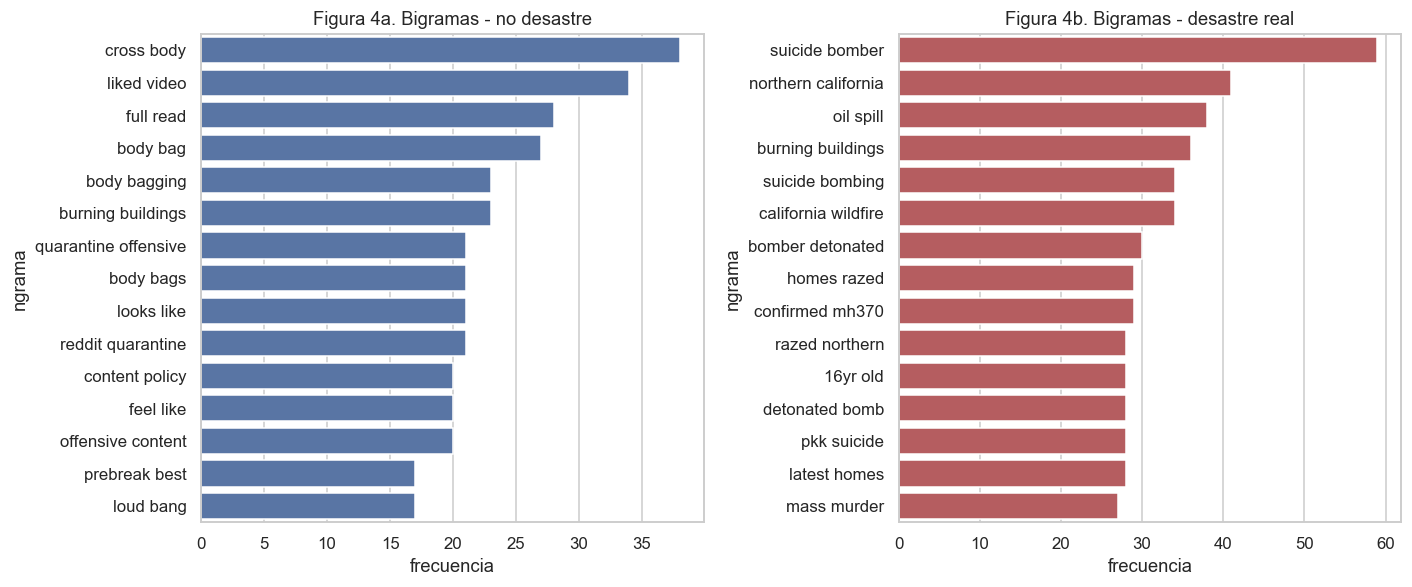

In [9]:
display(pd.concat({"No desastre": bigramas_0, "Desastre real": bigramas_1}, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(data=bigramas_0, y="ngrama", x="frecuencia", color="#4C72B0", ax=axes[0])
axes[0].set_title("Figura 4a. Bigramas - no desastre")
sns.barplot(data=bigramas_1, y="ngrama", x="frecuencia", color="#C44E52", ax=axes[1])
axes[1].set_title("Figura 4b. Bigramas - desastre real")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_bigramas.png", bbox_inches="tight")
plt.show()

In [10]:
display(pd.concat({"No desastre": trigramas_0, "Desastre real": trigramas_1}, axis=1))

No desastre                          \
                         ngrama frecuencia probabilidad   
0   reddit quarantine offensive         21     0.000761   
1  quarantine offensive content         20     0.000725   
2                cross body bag         19     0.000688   
3                 pick fan army         17     0.000616   
4           reddits new content         16     0.000580   
5            new content policy         16     0.000580   
6            stock market crash         16     0.000580   
7          effect many horrible         15     0.000543   
8      many horrible subreddits         15     0.000543   
9    horrible subreddits banned         15     0.000543   

                  Desastre real                          
                         ngrama frecuencia probabilidad  
0      suicide bomber detonated         30     0.001263  
1  northern california wildfire         29     0.001220  
2         bomber detonated bomb         28     0.001178  
3            pkk suicide bomber         28     0.001178  
4          homes razed northern         28     0.001178  
5            latest homes razed         28     0.001178  
6     razed northern california         27     0.001136  
7                  16yr old pkk         27     0.001136  
8               old pkk suicide         27     0.001136  
9       families affected fatal         26     0.001094

Los bigramas si agregan contexto: combinaciones como `suicide bomber`, `oil spill` y `northern california` son más especificas que sus palabras por separado. Los trigramas son interpretables, pero se repiten poco debido a la longitud de los tweets; por eso se prueban en el análisis y se deja que la validación determine si conviene usarlos en el modelo.

## 5. Analisis exploratorio adicional

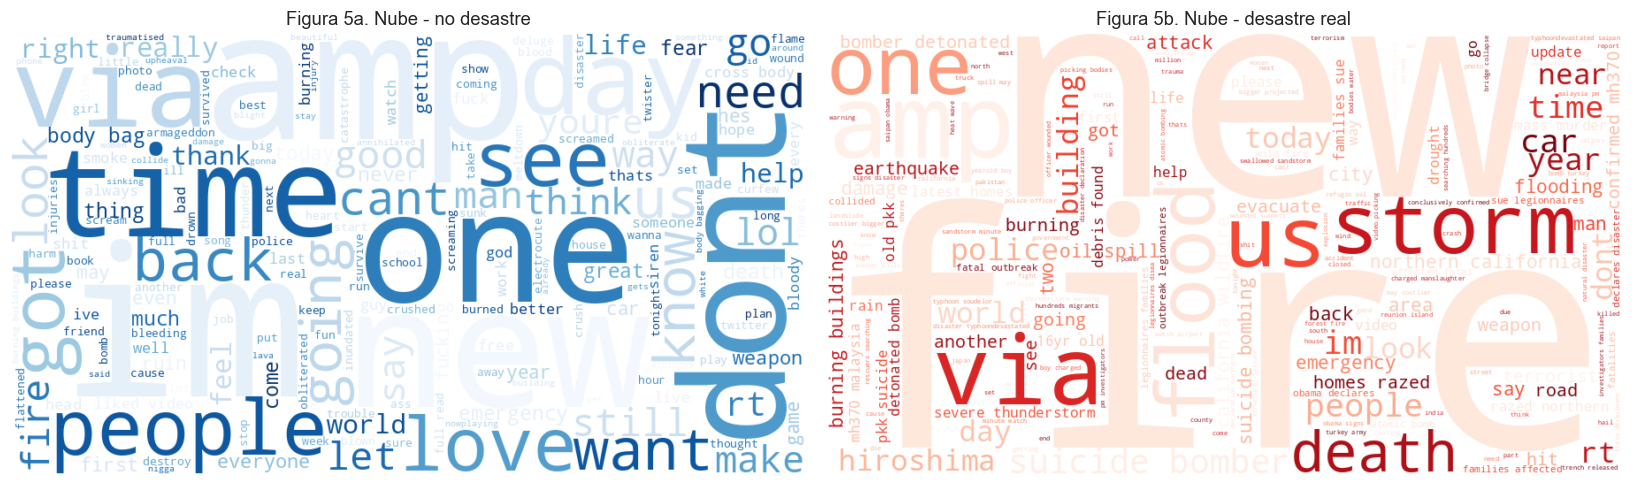

In [11]:
texto_0 = " ".join(train.loc[train.target == 0, "text_clean"])
texto_1 = " ".join(train.loc[train.target == 1, "text_clean"])

wc0 = WordCloud(width=900, height=500, background_color="white",
                colormap="Blues", random_state=42).generate(texto_0)
wc1 = WordCloud(width=900, height=500, background_color="white",
                colormap="Reds", random_state=42).generate(texto_1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(wc0, interpolation="bilinear")
axes[0].set_title("Figura 5a. Nube - no desastre")
axes[0].axis("off")
axes[1].imshow(wc1, interpolation="bilinear")
axes[1].set_title("Figura 5b. Nube - desastre real")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_nubes.png", bbox_inches="tight")
plt.show()

In [12]:
top100_0 = set(tabla_ngramas(train.loc[train.target == 0, "text_clean"], 1, 100)["ngrama"])
top100_1 = set(tabla_ngramas(train.loc[train.target == 1, "text_clean"], 1, 100)["ngrama"])
comunes = sorted(top100_0 & top100_1)
print(f"Hay {len(comunes)} palabras compartidas entre los 100 unigramas principales:")
print(comunes)

Hay 26 palabras compartidas entre los 100 unigramas principales:
['amp', 'back', 'burning', 'could', 'death', 'dont', 'emergency', 'fire', 'first', 'get', 'im', 'like', 'man', 'may', 'new', 'news', 'one', 'people', 'rt', 'say', 'still', 'today', 'us', 'via', 'video', 'world']


Las palabras compartidas son menos discriminativas por si solas. Entre ellas aparecen `fire`, `disaster`, `emergency`, `people`, `news`, `video` y `world`. La presencia en ambos grupos respalda el uso de TF-IDF: los términos demasiado comunes reciben menor peso, y los bigramas permiten recuperar parte del contexto.

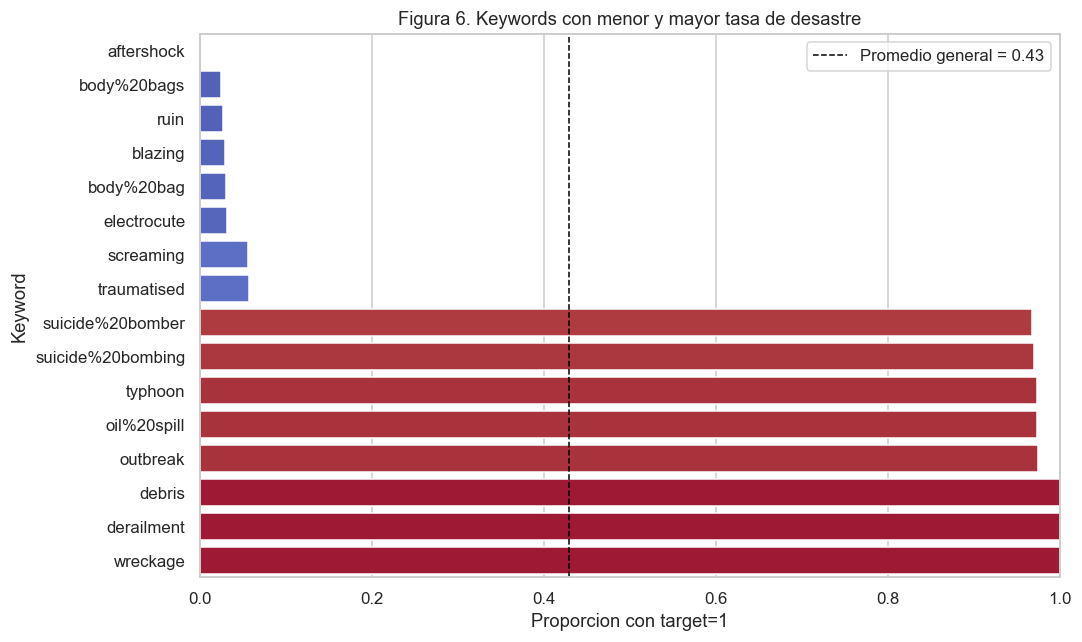

,keyword,tweets,tasa_desastre
0,aftershock,34,0.000000
1,body%20bags,41,0.024390
2,ruin,37,0.027027
3,blazing,34,0.029412
4,body%20bag,33,0.030303
5,electrocute,32,0.031250
6,screaming,36,0.055556
7,traumatised,35,0.057143
8,suicide%20bomber,31,0.967742
9,suicide%20bombing,33,0.969697


In [13]:
keyword_stats = (
    train.dropna(subset=["keyword"])
         .groupby("keyword")["target"]
         .agg(tweets="size", tasa_desastre="mean")
         .query("tweets >= 20")
         .sort_values("tasa_desastre")
)

keywords_grafica = pd.concat([keyword_stats.head(8), keyword_stats.tail(8)]).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=keywords_grafica, y="keyword", x="tasa_desastre",
            hue="tasa_desastre", palette="coolwarm", legend=False, ax=ax)
ax.axvline(train.target.mean(), color="black", linestyle="--", linewidth=1,
           label=f"Promedio general = {train.target.mean():.2f}")
ax.set(title="Figura 6. Keywords con menor y mayor tasa de desastre",
       xlabel="Proporcion con target=1", ylabel="Keyword", xlim=(0, 1))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_keywords.png", bbox_inches="tight")
plt.show()

display(keywords_grafica)

El cruce de `keyword` con `target` muestra extremos claros, pero también keywords ambiguas. Por ejemplo, una misma palabra puede describir un hecho o usarse en una broma. Esto explica por qué una regla basada solamente en keywords sería fragil.

## 6. Modelos de clasificación

Primero se reserva 20% de los datos para prueba con `random_state=42` y estratificación. El 80% restante se usa en validación cruzada de cinco particiones. Se comparan:

- **Naive Bayes multinomial:** usa conteos de unigramas y bigramas.
- **Regresion logística:** usa TF-IDF de unigramas y bigramas.
- **SVM lineal:** usa la misma representación TF-IDF.
- **Regresion logística con trigramas:** permite comprobar si el contexto adicional compensa la dispersión.

TF-IDF reduce el peso de palabras frecuentes en casi todos los documentos y favorece términos que distinguen tweets. Los n-gramas permiten representar parte del contexto sin requerir un modelo profundo.

In [14]:
indices_train, indices_test = train_test_split(
    train.index, test_size=0.20, random_state=42, stratify=train["target"]
)
X_train = train.loc[indices_train, "text_clean"]
X_test = train.loc[indices_test, "text_clean"]
y_train = train.loc[indices_train, "target"]
y_test = train.loc[indices_test, "target"]

baseline_mayoritaria = y_train.value_counts(normalize=True).max()
print(f"Baseline de la clase mayoritaria: {baseline_mayoritaria:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidatos = {
    "Naive Bayes + conteos (1,2)": Pipeline([
        ("vectorizador", CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("modelo", MultinomialNB(alpha=0.5))
    ]),
    "Regresion logistica + TF-IDF (1,2)": Pipeline([
        ("vectorizador", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=10000)),
        ("modelo", LogisticRegression(C=1, max_iter=2000, random_state=42))
    ]),
    "SVM lineal + TF-IDF (1,2)": Pipeline([
        ("vectorizador", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("modelo", LinearSVC(C=1, max_iter=10000, random_state=42))
    ]),
    "Regresion logistica + TF-IDF (1,3)": Pipeline([
        ("vectorizador", TfidfVectorizer(ngram_range=(1, 3), min_df=2, max_features=20000)),
        ("modelo", LogisticRegression(C=1, max_iter=2000, random_state=42))
    ])
}

filas_cv = []
for nombre, modelo in candidatos.items():
    scores = cross_validate(
        modelo, X_train, y_train, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"], n_jobs=1
    )
    filas_cv.append({
        "modelo": nombre,
        "accuracy_cv": scores["test_accuracy"].mean(),
        "precision_cv": scores["test_precision"].mean(),
        "recall_cv": scores["test_recall"].mean(),
        "f1_cv": scores["test_f1"].mean(),
        "desv_f1": scores["test_f1"].std()
    })

resultados_cv = pd.DataFrame(filas_cv).sort_values("f1_cv", ascending=False)
display(resultados_cv.style.format({c: "{:.4f}" for c in resultados_cv.columns if c != "modelo"}))

Baseline de la clase mayoritaria: 0.5703


,modelo,accuracy_cv,precision_cv,recall_cv,f1_cv,desv_f1
0,"Naive Bayes + conteos (1,2)",0.7957,0.8154,0.6790,0.7406,0.0116
1,"Regresion logistica + TF-IDF (1,2)",0.7966,0.8293,0.6641,0.7372,0.0109
3,"Regresion logistica + TF-IDF (1,3)",0.7959,0.8274,0.6645,0.7367,0.0121
2,"SVM lineal + TF-IDF (1,2)",0.7764,0.7558,0.7096,0.7316,0.0156


Naive Bayes obtiene el mayor F1 en la comparación inicial (0.7406), pero la regresión logística queda dentro de una diferencia pequeña y permite obtener probabilidades directamente. Por eso se ajusta la regresión logística para comprobar si una mejor regularización supera ese punto de referencia. Los trigramas no mejoran el resultado de forma consistente, lo cual coincide con su baja frecuencia observada.

Para no escoger `C` mirando el conjunto de prueba, se ajusta este hiperparámetro dentro del 80% de entrenamiento mediante validación cruzada. También se prueban `min_df` y el límite de vocabulario.

In [15]:
pipeline_rl = Pipeline([
    ("vectorizador", TfidfVectorizer()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

parametros = {
    "vectorizador__ngram_range": [(1, 1), (1, 2)],
    "vectorizador__min_df": [1, 2],
    "vectorizador__max_features": [10000, 20000],
    "modelo__C": [0.5, 1, 2]
}

busqueda = GridSearchCV(
    pipeline_rl, parametros, scoring="f1", cv=cv,
    n_jobs=1, return_train_score=False
)
busqueda.fit(X_train, y_train)

print("Mejor F1 promedio de validacion:", round(busqueda.best_score_, 4))
print("Parametros seleccionados:", busqueda.best_params_)

Mejor F1 promedio de validacion: 0.7424
Parametros seleccionados: {'modelo__C': 2, 'vectorizador__max_features': 10000, 'vectorizador__min_df': 2, 'vectorizador__ngram_range': (1, 2)}


,accuracy,precision,recall,f1
TF-IDF + regresion logistica,0.8234,0.8313,0.7385,0.7822


               precision    recall  f1-score   support

  No desastre       0.82      0.89      0.85       869
Desastre real       0.83      0.74      0.78       654

     accuracy                           0.82      1523
    macro avg       0.82      0.81      0.82      1523
 weighted avg       0.82      0.82      0.82      1523



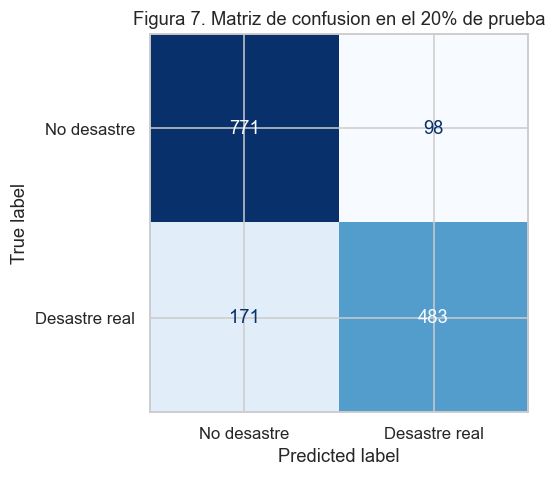

In [16]:
mejor_modelo = busqueda.best_estimator_
pred_test = mejor_modelo.predict(X_test)

metricas_base = {
    "accuracy": accuracy_score(y_test, pred_test),
    "precision": precision_score(y_test, pred_test),
    "recall": recall_score(y_test, pred_test),
    "f1": f1_score(y_test, pred_test)
}
display(pd.DataFrame([metricas_base], index=["TF-IDF + regresion logistica"]).round(4))
print(classification_report(y_test, pred_test, target_names=["No desastre", "Desastre real"]))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=["No desastre", "Desastre real"],
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Figura 7. Matriz de confusion en el 20% de prueba")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_matriz_confusion.png", bbox_inches="tight")
plt.show()

El modelo final alcanza aproximadamente **82.34% de exactitud y F1=0.7822** en los datos reservados. De 1,523 tweets, clasifica correctamente 771 no desastres y 483 desastres. Los 171 falsos negativos son el error más delicado, porque corresponden a desastres reales que el modelo no detecta. El recall de la clase desastre es 73.85%; si la aplicacion priorizara alertas, podria reducirse el umbral para recuperar más casos a costa de más falsos positivos.

## 7. Funcion para clasificar tweets nuevos

La función recibe texto sin preprocesar, aplica exactamente la misma limpieza y el mismo vectorizador del entrenamiento, y devuelve la clase junto con su probabilidad. Finalmente se reentrena el modelo seleccionado con las 7,613 observaciones para aprovechar todos los datos disponibles.

In [17]:
modelo_produccion = clone(mejor_modelo).fit(train["text_clean"], train["target"])

def clasificar_tweet(tweet):
    '''Clasifica un tweet crudo y devuelve clase, etiqueta y probabilidad.'''
    texto_limpio = limpiar_texto(tweet)
    clase = int(modelo_produccion.predict([texto_limpio])[0])
    probabilidad = float(modelo_produccion.predict_proba([texto_limpio])[0, 1])
    return {
        "clasificacion": "Desastre real" if clase == 1 else "No desastre",
        "target": clase,
        "probabilidad_desastre": round(probabilidad, 4)
    }

ejemplos = [
    "Wildfire forces families to evacuate near the highway",
    "My homework is a complete disaster lol",
    "Emergency crews rescue people after severe flooding"
]
for ejemplo in ejemplos:
    print(ejemplo)
    print(clasificar_tweet(ejemplo), "\n")

Wildfire forces families to evacuate near the highway
{'clasificacion': 'Desastre real', 'target': 1, 'probabilidad_desastre': 0.9654} 

My homework is a complete disaster lol
{'clasificacion': 'No desastre', 'target': 0, 'probabilidad_desastre': 0.2367} 

Emergency crews rescue people after severe flooding
{'clasificacion': 'Desastre real', 'target': 1, 'probabilidad_desastre': 0.8893} 



Los ejemplos permiten revisar tanto un mensaje literal como uno figurado. La función satisface el requisito de aceptar texto crudo: el usuario no necesita quitar URL, menciones o puntuación antes de llamar al modelo.

## 8. Analisis de sentimiento

Se usa **VADER** (`SentimentIntensityAnalyzer` de NLTK), un método basado en léxico y reglas diseñado para texto corto de redes sociales. VADER devuelve proporciones positiva, negativa y neutra, además de `compound`, una puntuación normalizada entre -1 y 1.

Se aplican los umbrales sugeridos por VADER:

- positivo: `compound >= 0.05`;
- negativo: `compound <= -0.05`;
- neutro: valores intermedios.

Los emoticones y la puntuación se conservan en esta etapa porque VADER puede usarlos como intensificadores. Referencia: Hutto y Gilbert (2014), [VADER: A Parsimonious Rule-Based Model for Sentiment Analysis of Social Media Text](https://doi.org/10.1609/icwsm.v8i1.14550).

In [18]:
analizador_sentimiento = SentimentIntensityAnalyzer()
puntajes = train["text"].apply(analizador_sentimiento.polarity_scores).apply(pd.Series)
puntajes.columns = ["sent_neg", "sent_neu", "sent_pos", "sent_compound"]
train = pd.concat([train, puntajes], axis=1)

train["sentimiento"] = np.select(
    [train["sent_compound"] >= 0.05, train["sent_compound"] <= -0.05],
    ["Positivo", "Negativo"], default="Neutro"
)

def contar_palabras_por_valencia(texto):
    '''Cuenta ocurrencias positivas, negativas y neutras segun el lexico de VADER.'''
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", str(texto).lower())
    positivas = [t for t in tokens if analizador_sentimiento.lexicon.get(t, 0) > 0]
    negativas = [t for t in tokens if analizador_sentimiento.lexicon.get(t, 0) < 0]
    neutras = [t for t in tokens if analizador_sentimiento.lexicon.get(t, 0) == 0]
    return pd.Series({
        "n_palabras_positivas": len(positivas),
        "n_palabras_negativas": len(negativas),
        "n_palabras_neutras": len(neutras),
        "palabras_positivas": ", ".join(positivas),
        "palabras_negativas": ", ".join(negativas)
    })

conteos_valencia = train["text"].apply(contar_palabras_por_valencia)
train = pd.concat([train, conteos_valencia], axis=1)

tabla_sentimiento = pd.crosstab(train["target"], train["sentimiento"])
tabla_sentimiento_pct = pd.crosstab(
    train["target"], train["sentimiento"], normalize="index"
).mul(100).round(2)

display(tabla_sentimiento)
display(tabla_sentimiento_pct)

sentimiento,Negativo,Neutro,Positivo
target,,,
0,1846,1133,1363
1,1861,880,530


sentimiento,Negativo,Neutro,Positivo
target,,,
0,42.51,26.09,31.39
1,56.89,26.90,16.20


### 8.1 Palabras positivas, negativas y neutras

Para atender literalmente el conteo solicitado, cada token se consulta en el léxico de VADER. Una palabra con valencia mayor que cero se cuenta como positiva, una con valencia menor que cero como negativa y una sin valencia asignada se cuenta como neutra. Los conteos representan ocurrencias, por lo que una palabra repetida se cuenta cada vez.

La etiqueta final del tweet se mantiene basada en `compound`, no solo en la diferencia de conteos. Esto es importante porque VADER también considera negaciones, intensificadores, mayúsculas, puntuación y emoticones al calcular el sentimiento del mensaje completo.

In [19]:
columnas_conteo = [
    "text", "palabras_positivas", "palabras_negativas",
    "n_palabras_positivas", "n_palabras_negativas", "n_palabras_neutras",
    "sent_compound", "sentimiento"
]
ejemplos_conteo = pd.concat([
    train.nsmallest(3, "sent_compound"),
    train.nlargest(3, "sent_compound")
])[columnas_conteo]
display(ejemplos_conteo)

resumen_conteos = train.groupby("sentimiento")[[
    "n_palabras_positivas", "n_palabras_negativas", "n_palabras_neutras"
]].mean().round(2)
display(resumen_conteos)

,text,palabras_positivas,palabras_negativas,n_palabras_positivas,n_palabras_negativas,n_palabras_neutras,sent_compound,sentimiento
7472,wreck? wreck wreck wreck wreck wreck wreck wre...,,"wreck, wreck, wreck, wreck, wreck, wreck, wrec...",0,13,0,-0.9883,Negativo
6414,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...,,"suicide, dead, suicide, dead, ridiculous",0,5,16,-0.9686,Negativo
6411,Suicide bomber kills 15 in Saudi security site...,security,"suicide, kills, suicide, killed, attack",1,5,20,-0.9623,Negativo
6992,Check out 'Want Twister Tickets AND A VIP EXPE...,"want, vip, love, love, love, win",,6,0,21,0.9730,Positivo
6534,@thoutaylorbrown I feel like accidents are jus...,"like, happy, survived, hope, okay",accidents,5,1,15,0.9564,Positivo
6292,TodayÛªs storm will pass; let tomorrowÛªs li...,"greet, kiss, loving, warmth, bliss",,5,0,20,0.9471,Positivo


,n_palabras_positivas,n_palabras_negativas,n_palabras_neutras
sentimiento,,,
Negativo,0.36,1.66,15.54
Neutro,0.16,0.12,15.41
Positivo,1.53,0.49,15.94


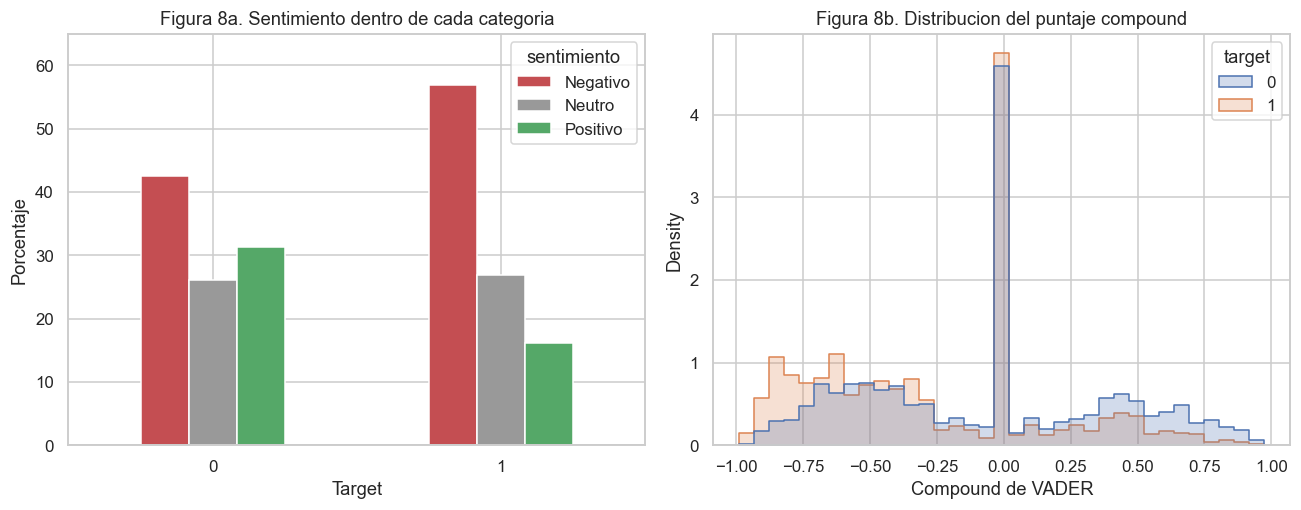

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
tabla_sentimiento_pct[["Negativo", "Neutro", "Positivo"]].plot(
    kind="bar", color=["#C44E52", "#999999", "#55A868"], ax=axes[0]
)
axes[0].set(title="Figura 8a. Sentimiento dentro de cada categoria",
            xlabel="Target", ylabel="Porcentaje", ylim=(0, 65))
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(data=train, x="sent_compound", hue="target", bins=35,
             element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set(title="Figura 8b. Distribucion del puntaje compound",
            xlabel="Compound de VADER")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_sentimientos.png", bbox_inches="tight")
plt.show()

En todo el conjunto se obtienen 3,707 tweets negativos, 2,013 neutros y 1,893 positivos. Entre los desastres reales, 56.89% son negativos y 16.20% positivos. En la clase que no corresponde a desastre, 42.52% son negativos y 31.39% positivos. Hay solapamiento porque VADER mide tono, no veracidad: un tweet puede ser muy negativo sin informar un desastre real.

### 8.2 Los 10 tweets más negativos y los 10 más positivos

In [21]:
columnas_extremos = ["id", "target", "sent_compound", "sent_neg", "sent_pos", "text"]
top_negativos = train.nsmallest(10, "sent_compound")[columnas_extremos]
top_positivos = train.nlargest(10, "sent_compound")[columnas_extremos]

print("Diez tweets mas negativos")
display(top_negativos)
print("Categorias:", top_negativos["target"].value_counts().sort_index().to_dict())

print("Diez tweets mas positivos")
display(top_positivos)
print("Categorias:", top_positivos["target"].value_counts().sort_index().to_dict())

Diez tweets mas negativos


,id,target,sent_compound,sent_neg,sent_pos,text
7472,10689,0,-0.9883,1.000,0.000,wreck? wreck wreck wreck wreck wreck wreck wre...
6414,9172,1,-0.9686,0.542,0.000,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...
6411,9166,1,-0.9623,0.536,0.064,Suicide bomber kills 15 in Saudi security site...
6393,9137,1,-0.9595,0.583,0.000,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...
6407,9159,1,-0.9552,0.579,0.000,17 killed in SÛªArabia mosque suicide bombing...
2932,4213,0,-0.9549,0.538,0.000,at the lake \n*sees a dead fish*\nme: poor lit...
472,682,1,-0.9538,0.536,0.000,illegal alien released by Obama/DHS 4 times Ch...
1540,2225,1,-0.9524,0.566,0.096,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...
6818,9765,1,-0.9500,0.481,0.000,Bomb head? Explosive decisions dat produced mo...
6930,9940,1,-0.9493,0.481,0.060,@cspan #Prez. Mr. President you are the bigges...


Categorias: {0: 2, 1: 8}
Diez tweets mas positivos


,id,target,sent_compound,sent_neg,sent_pos,text
6992,10028,0,0.9730,0.000,0.598,Check out 'Want Twister Tickets AND A VIP EXPE...
6534,9345,0,0.9564,0.049,0.539,@thoutaylorbrown I feel like accidents are jus...
6292,8989,1,0.9471,0.000,0.491,TodayÛªs storm will pass; let tomorrowÛªs li...
3163,4541,0,0.9423,0.084,0.563,@batfanuk we enjoyed the show today. Great fun...
3382,4844,0,0.9423,0.084,0.563,@batfanuk we enjoyed the show today. Great fun...
6778,9710,0,0.9394,0.000,0.619,Maaaaan I love Love Without Tragedy by @rihann...
6295,8994,0,0.9376,0.000,0.607,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...
2457,3525,1,0.9356,0.000,0.575,@Raishimi33 :) well I think that sounds like a...
1001,1453,0,0.9345,0.061,0.566,I'm not a Drake fan but I enjoy seeing him bod...
6560,9386,0,0.9344,0.000,0.538,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...


Categorias: {0: 8, 1: 2}


Ocho de los diez tweets más negativos pertenecen a la categoría de desastre real. Los dos casos con `target=0` muestran que un tono muy negativo no implica necesariamente un desastre real; uno de ellos repite la palabra `wreck`. En los diez más positivos, ocho tienen `target=0` y dos tienen `target=1`. Estos casos muestran una limitación del análisis lexicográfico: el tono emocional y la categoría de desastre están relacionados, pero no son equivalentes.

### 8.3 ¿Los tweets de desastres reales son más negativos?

In [22]:
resumen_sentimiento = train.groupby("target").agg(
    tweets=("id", "size"),
    compound_promedio=("sent_compound", "mean"),
    compound_mediana=("sent_compound", "median"),
    negatividad_promedio=("sent_neg", "mean"),
    porcentaje_negativos=("sentimiento", lambda s: 100 * (s == "Negativo").mean()),
    porcentaje_positivos=("sentimiento", lambda s: 100 * (s == "Positivo").mean())
).round(4)
display(resumen_sentimiento)

compound_desastre = train.loc[train.target == 1, "sent_compound"]
compound_no_desastre = train.loc[train.target == 0, "sent_compound"]
u_stat, p_value = mannwhitneyu(
    compound_desastre, compound_no_desastre, alternative="less"
)

var_pooled = (
    ((len(compound_desastre)-1) * compound_desastre.var(ddof=1) +
     (len(compound_no_desastre)-1) * compound_no_desastre.var(ddof=1)) /
    (len(compound_desastre) + len(compound_no_desastre) - 2)
)
cohen_d = (compound_desastre.mean() - compound_no_desastre.mean()) / np.sqrt(var_pooled)

print(f"Mann-Whitney U = {u_stat:,.1f}")
print(f"p-valor unilateral = {p_value:.3e}")
print(f"d de Cohen = {cohen_d:.3f}")

,tweets,compound_promedio,compound_mediana,negatividad_promedio,porcentaje_negativos,porcentaje_positivos
target,,,,,,
0,4342,-0.0606,0.0000,0.1323,42.5150,31.3911
1,3271,-0.2646,-0.3182,0.1736,56.8939,16.2030


Mann-Whitney U = 5,335,958.5
p-valor unilateral = 8.669e-79
d de Cohen = -0.458


Sí: los tweets de desastre real son más negativos. Su `compound` promedio es **-0.2646**, frente a **-0.0606** para los que no son desastre; las medianas son -0.3182 y 0.0000. La prueba unilateral de Mann-Whitney produce un p-valor menor que 0.001, y el tamaño de efecto `d=-0.458` es moderado. La diferencia es estadísticamente clara, aunque las distribuciones se solapan y no permiten clasificar por sentimiento solamente.

## 9. Variable de negatividad y reentrenamiento

Se define `negatividad` como la proporción `neg` de VADER, entre 0 y 1. Para aislar su aporte se reutilizan exactamente los mismos indices de entrenamiento/prueba, el mismo vocabulario TF-IDF y los mismos parametros de regresión logística. La única diferencia es una columna adicional al final de la matriz dispersa.

,accuracy,precision,recall,f1,cambio_f1
TF-IDF,0.8234,0.8313,0.7385,0.7822,0.0000
TF-IDF + negatividad,0.8221,0.8330,0.7324,0.7795,-0.0027


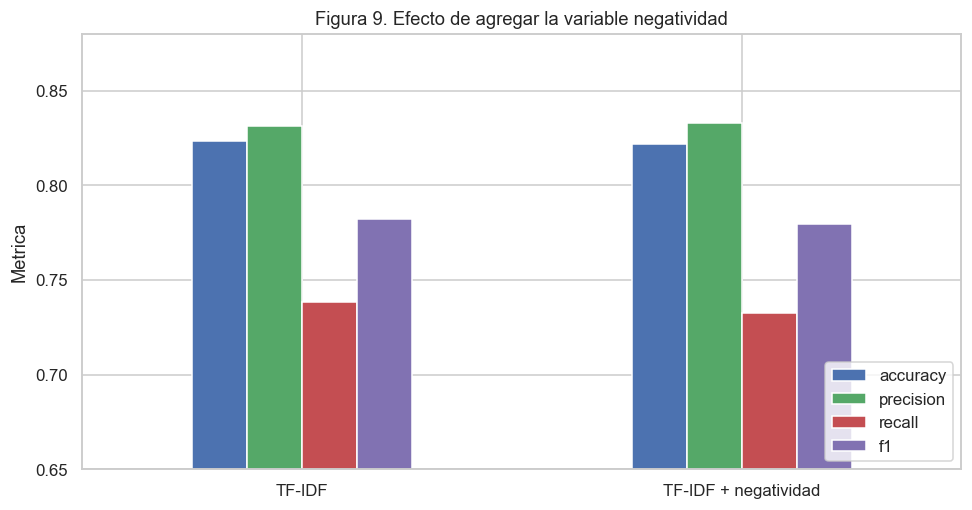

In [23]:
train["negatividad"] = train["sent_neg"]

vectorizador_comparacion = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=10000
)
Xtr_tfidf = vectorizador_comparacion.fit_transform(train.loc[indices_train, "text_clean"])
Xte_tfidf = vectorizador_comparacion.transform(train.loc[indices_test, "text_clean"])

modelo_sin_neg = LogisticRegression(C=2, max_iter=2000, random_state=42)
modelo_sin_neg.fit(Xtr_tfidf, y_train)
pred_sin_neg = modelo_sin_neg.predict(Xte_tfidf)

Xtr_neg = hstack([
    Xtr_tfidf,
    csr_matrix(train.loc[indices_train, "negatividad"].to_numpy().reshape(-1, 1))
], format="csr")
Xte_neg = hstack([
    Xte_tfidf,
    csr_matrix(train.loc[indices_test, "negatividad"].to_numpy().reshape(-1, 1))
], format="csr")

modelo_con_neg = LogisticRegression(C=2, max_iter=2000, random_state=42)
modelo_con_neg.fit(Xtr_neg, y_train)
pred_con_neg = modelo_con_neg.predict(Xte_neg)

def calcular_metricas(y_real, pred):
    return {
        "accuracy": accuracy_score(y_real, pred),
        "precision": precision_score(y_real, pred),
        "recall": recall_score(y_real, pred),
        "f1": f1_score(y_real, pred)
    }

comparacion = pd.DataFrame({
    "TF-IDF": calcular_metricas(y_test, pred_sin_neg),
    "TF-IDF + negatividad": calcular_metricas(y_test, pred_con_neg)
}).T
comparacion["cambio_f1"] = comparacion["f1"] - comparacion.loc["TF-IDF", "f1"]
display(comparacion.round(4))

ax = comparacion[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar", figsize=(9, 4.8), ylim=(0.65, 0.88), color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
)
ax.set(title="Figura 9. Efecto de agregar la variable negatividad", ylabel="Metrica")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_comparacion_negatividad.png", bbox_inches="tight")
plt.show()

In [24]:
# Se guarda el conjunto enriquecido y las tablas principales para reproducir el informe.
train.to_csv(ROOT / "reporte" / "train_con_sentimiento.csv", index=False)
resultados_cv.to_csv(ROOT / "reporte" / "resultados_validacion_cruzada.csv", index=False)
pd.concat({"negativos": top_negativos, "positivos": top_positivos}).to_csv(
    ROOT / "reporte" / "tweets_extremos.csv"
)
print("Resultados guardados en", (ROOT / "reporte").resolve())

Resultados guardados en C:\Users\mdax8\Desktop\UVG\8 Semestre\Data Science\Lab 5\Data_Science\Lab-MineriayAnalisis\reporte


La negatividad **no mejoro** el modelo. La exactitud pasa de 0.8234 a 0.8221 (-0.13 puntos porcentuales) y F1 de 0.7822 a 0.7795 (-0.27 puntos porcentuales). Aunque los desastres reales son más negativos en promedio, TF-IDF ya contiene palabras como `killed`, `bomb`, `death` y `love`, de las que VADER deriva su puntaje. La nueva columna resulta redundante y no se incluye en la función final.

## 10. Conclusiones

1. Las clases están razonablemente balanceadas: 57% no desastre y 43% desastre real. `location` tiene demasiados nulos y variación para usarla directamente.
2. La limpieza conserva hashtags como palabras y mantiene `911`, pero elimina ruido para las frecuencias y TF-IDF. En sentimiento se usa el texto crudo para no perder emoticones, mayúsculas y puntuación.
3. Los unigramas separan parte del problema; los bigramas ayudan con contexto. Los trigramas son demasiado dispersos para producir una mejora consistente.
4. La mejor configuración fue TF-IDF de unigramas/bigramas con regresión logística. En el 20% reservado obtuvo 82.34% de exactitud y F1=0.7822.
5. Los tweets de desastre real son más negativos en promedio. Aun asi, el tono no determina por si solo si el evento es real.
6. Agregar la variable de negatividad no mejora el clasificador. Se conserva el modelo de texto sin esta columna.

### Limitaciones

- El modelo lineal no comprende sarcasmo, ironia ni conocimiento del mundo.
- VADER usa un léxico general de redes sociales y puede confundir repeticion, nombres o texto mal codificado con intensidad afectiva.
- Los resultados corresponden a este conjunto de Kaggle; antes de usar el sistema en una emergencia real se necesitaría validación con datos recientes y un análisis del costo de los falsos negativos.

## Referencias

- Kaggle. *Natural Language Processing with Disaster Tweets*. https://www.kaggle.com/competitions/nlp-getting-started/overview
- Hutto, C. J. y Gilbert, E. (2014). *VADER: A Parsimonious Rule-Based Model for Sentiment Analysis of Social Media Text*. Proceedings of ICWSM, 8(1), 216-225. https://doi.org/10.1609/icwsm.v8i1.14550
- NLTK Project. *Sample usage for sentiment*. https://www.nltk.org/howto/sentiment.html
- Scikit-learn Developers. *Working with text data*. https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html
- Jurafsky, D. y Martin, J. H. *Speech and Language Processing*. https://web.stanford.edu/~jurafsky/slp3/